# Week 2 – Day 1: Dataset Readiness, Preprocessing & Feature Engineering

## Introduction
Today we focus on preparing data before machine learning model training. This stage is often called **data readiness** in the machine learning workflow.

Good preprocessing helps us:
- improve data quality
- make features usable by machine learning algorithms
- reduce errors caused by missing values, duplicates, or extreme values
- organize repeatable preprocessing steps in a pipeline

## 1) Import Libraries
We import only the tools needed for Day 1 data preparation.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Make plots appear inside the notebook
%matplotlib inline

### Why these imports?
- `pandas`: table-like data handling (`DataFrame`).
- `numpy`: numerical operations and reproducible random generation.
- `matplotlib.pyplot`: basic plotting (boxplots and line plots).
- `SimpleImputer`: fills missing values in a consistent way.
- `OneHotEncoder`: converts categorical columns into numeric indicator columns.
- `StandardScaler`: scales numeric values to mean 0 and standard deviation 1.
- `MinMaxScaler`: scales numeric values to a 0 to 1 range.
- `ColumnTransformer`: applies different preprocessing to numeric and categorical columns.
- `Pipeline`: chains steps together so preprocessing is reproducible and clean.

## 2) Create and Save a Sample Dataset
We generate a realistic housing/energy dataset with reproducible randomness.

Design logic:
- larger houses usually consume more energy
- older buildings usually consume more energy
- colder average temperature increases energy consumption
- poorer insulation increases energy consumption
- heating type affects consumption

We intentionally include:
- missing values (numeric and categorical)
- duplicates
- outliers
- random noise

In [2]:
import os
# Fixed seed for reproducibility
seed = 42
rng = np.random.default_rng(seed)
n_rows = 120

house_size_m2 = np.clip(rng.normal(130, 45, n_rows), 40, 420)
bedrooms = np.clip(np.round(house_size_m2 / 35 + rng.normal(0, 1, n_rows)), 1, 8).astype(int)
building_age_years = np.clip(rng.normal(32, 20, n_rows), 1, 100)
city = rng.choice(['Berlin', 'Munich', 'Hamburg', 'Cologne', 'Leipzig'], size=n_rows, p=[0.25, 0.2, 0.2, 0.2, 0.15])
heating_type = rng.choice(['Gas', 'Electric', 'Heat Pump', 'District'], size=n_rows, p=[0.4, 0.25, 0.2, 0.15])
insulation_grade = rng.choice(['A', 'B', 'C', 'D'], size=n_rows, p=[0.2, 0.35, 0.3, 0.15])
average_temperature_c = np.clip(rng.normal(11, 5, n_rows), -5, 24)

insulation_effect = pd.Series(insulation_grade).map({'A': -1300, 'B': -600, 'C': 200, 'D': 1000}).to_numpy()
heating_effect = pd.Series(heating_type).map({'Heat Pump': -800, 'District': -300, 'Gas': 200, 'Electric': 500}).to_numpy()
city_effect = pd.Series(city).map({'Berlin': 100, 'Munich': 250, 'Hamburg': 150, 'Cologne': 80, 'Leipzig': -50}).to_numpy()
noise = rng.normal(0, 350, n_rows)

energy_consumption_kwh = (
    3500
    + 24 * house_size_m2
    + 16 * building_age_years
    + (14 - average_temperature_c) * 170
    + insulation_effect
    + heating_effect
    + city_effect
    + noise
)
energy_consumption_kwh = np.clip(energy_consumption_kwh, 1500, None)

df_generated = pd.DataFrame({
    'house_size_m2': house_size_m2.round(1),
    'bedrooms': bedrooms,
    'building_age_years': building_age_years.round(1),
    'city': city,
    'heating_type': heating_type,
    'insulation_grade': insulation_grade,
    'average_temperature_c': average_temperature_c.round(1),
    'energy_consumption_kwh': energy_consumption_kwh.round(1),
})

# Add a few extreme values (outliers)
df_generated.loc[5, ['house_size_m2', 'bedrooms', 'energy_consumption_kwh']] = [520, 10, 32000]
df_generated.loc[33, ['building_age_years', 'energy_consumption_kwh']] = [140, 26500]
df_generated.loc[87, ['average_temperature_c', 'energy_consumption_kwh']] = [-18, 29000]

# Add missing numerical values
for col in ['house_size_m2', 'building_age_years', 'average_temperature_c']:
    idx = rng.choice(df_generated.index, size=4, replace=False)
    df_generated.loc[idx, col] = np.nan

# Add missing categorical values
for col in ['city', 'heating_type', 'insulation_grade']:
    idx = rng.choice(df_generated.index, size=3, replace=False)
    df_generated.loc[idx, col] = np.nan

# Add duplicate rows
duplicates = df_generated.iloc[[10, 25]].copy()
df_generated = pd.concat([df_generated, duplicates], ignore_index=True)

# Save dataset
csv_path = '../../data/week2/day1_house_energy_sample.csv'
os.makedirs(os.path.dirname(csv_path), exist_ok=True)
df_generated.to_csv(csv_path, index=False)

print('Saved CSV to:', csv_path)
print('Generated dataset shape:', df_generated.shape)

Saved CSV to: data/week2/day1_house_energy_sample.csv
Generated dataset shape: (122, 8)


Now we load the saved file again to follow the normal real-world workflow (save -> load -> analyze).

In [3]:
df = pd.read_csv('../../data/week2/day1_house_energy_sample.csv')
df.head()

,house_size_m2,bedrooms,building_age_years,city,heating_type,insulation_grade,average_temperature_c,energy_consumption_kwh
0,143.7,3,14.5,Berlin,Heat Pump,B,16.2,4847.1
1,83.2,3,30.1,Berlin,Electric,C,6.1,8128.4
2,163.8,5,1.0,Leipzig,Electric,C,6.4,9391.3
3,172.3,6,2.7,Munich,Electric,B,13.8,7822.4
4,42.2,2,74.6,Munich,Gas,A,9.9,5979.5


## 3) First Look at the Dataset
These first checks help us understand structure, data types, and basic distributions before cleaning.

- `df.head()`: shows the first rows to quickly inspect values.
- `df.shape`: shows `(rows, columns)` to understand dataset size.
- `df.info()`: shows column names, non-null counts, and data types.
- `df.describe()`: summary statistics for numeric columns.
- `df.columns`: list of all column names.
- `df.dtypes`: data type of each column (numeric/object/etc.).

In [4]:
print('df.head():')
display(df.head())

print('df.shape:')
print(df.shape)

print('df.info():')
df.info()

print('\ndf.describe():')
display(df.describe())

print('df.columns:')
print(df.columns.tolist())

print('\ndf.dtypes:')
print(df.dtypes)

df.head():


,house_size_m2,bedrooms,building_age_years,city,heating_type,insulation_grade,average_temperature_c,energy_consumption_kwh
0,143.7,3,14.5,Berlin,Heat Pump,B,16.2,4847.1
1,83.2,3,30.1,Berlin,Electric,C,6.1,8128.4
2,163.8,5,1.0,Leipzig,Electric,C,6.4,9391.3
3,172.3,6,2.7,Munich,Electric,B,13.8,7822.4
4,42.2,2,74.6,Munich,Gas,A,9.9,5979.5


df.shape:
(122, 8)
df.info():
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122 entries, 0 to 121
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   house_size_m2           118 non-null    float64
 1   bedrooms                122 non-null    int64  
 2   building_age_years      118 non-null    float64
 3   city                    119 non-null    object 
 4   heating_type            119 non-null    object 
 5   insulation_grade        118 non-null    object 
 6   average_temperature_c   118 non-null    float64
 7   energy_consumption_kwh  122 non-null    float64
dtypes: float64(4), int64(1), object(3)
memory usage: 7.8+ KB

df.describe():


,house_size_m2,bedrooms,building_age_years,average_temperature_c,energy_consumption_kwh
count,118.000000,122.000000,118.000000,118.000000,122.000000
mean,131.422881,3.663934,34.155932,10.866102,8078.559016
std,50.169242,1.463668,21.698165,5.437119,3699.837453
min,42.200000,1.000000,1.000000,-18.000000,4247.100000
25%,107.375000,3.000000,20.300000,6.925000,6595.450000
50%,128.500000,4.000000,33.200000,11.250000,7760.650000
75%,154.300000,4.000000,46.900000,14.350000,8724.475000
max,520.000000,10.000000,140.000000,21.200000,32000.000000


df.columns:
['house_size_m2', 'bedrooms', 'building_age_years', 'city', 'heating_type', 'insulation_grade', 'average_temperature_c', 'energy_consumption_kwh']

df.dtypes:
house_size_m2             float64
bedrooms                    int64
building_age_years        float64
city                       object
heating_type               object
insulation_grade           object
average_temperature_c     float64
energy_consumption_kwh    float64
dtype: object


## 4) Define Target and Features
In supervised machine learning, the **target** is what we want to predict, and **features** are the input variables used for prediction.

In [5]:
y = df['energy_consumption_kwh']
X = df.drop(columns=['energy_consumption_kwh'])

print('Target shape:', y.shape)
print('Features shape:', X.shape)

Target shape: (122,)
Features shape: (122, 7)


Why separate `X` and `y`?
- It keeps input variables and prediction target clearly separated.
- Most scikit-learn workflows expect `X` and `y` as separate objects.
- It helps prevent accidental leakage of the target into input features.

| Column | Role | Type | Why useful |
|---|---|---|---|
| house_size_m2 | Feature | Numerical | Larger homes often use more energy |
| bedrooms | Feature | Numerical | Proxy for household size and house scale |
| building_age_years | Feature | Numerical | Older buildings may be less efficient |
| city | Feature | Categorical | Captures regional differences |
| heating_type | Feature | Categorical | Different systems have different usage patterns |
| insulation_grade | Feature | Categorical | Better insulation reduces energy use |
| average_temperature_c | Feature | Numerical | Colder weather usually increases heating demand |
| energy_consumption_kwh | Target | Numerical | Value we want to predict later |

## 5) Check Missing Values
Missing values can break algorithms or bias results if not handled correctly.

In [6]:
missing_count = df.isna().sum()
missing_percent = df.isna().mean() * 100

print('Missing value counts per column:')
display(missing_count)

print('Missing value percentage per column:')
display(missing_percent.round(2))

Missing value counts per column:


house_size_m2             4
bedrooms                  0
building_age_years        4
city                      3
heating_type              3
insulation_grade          4
average_temperature_c     4
energy_consumption_kwh    0
dtype: int64

Missing value percentage per column:


house_size_m2             3.28
bedrooms                  0.00
building_age_years        3.28
city                      2.46
heating_type              2.46
insulation_grade          3.28
average_temperature_c     3.28
energy_consumption_kwh    0.00
dtype: float64

- **Count** (`sum`) tells how many values are missing.
- **Percentage** (`mean * 100`) tells how severe missingness is relative to dataset size.
- Even small missingness can matter, especially in important columns.

## 6) Handle Missing Values Manually (Pandas First)
Before using scikit-learn pipelines, we practice simple manual imputation with pandas.

In [7]:
df_manual = df.copy()

numerical_cols = ['house_size_m2', 'bedrooms', 'building_age_years', 'average_temperature_c']
categorical_cols = ['city', 'heating_type', 'insulation_grade']

# Median imputation for numeric columns
for col in numerical_cols:
    median_value = df_manual[col].median()
    df_manual[col] = df_manual[col].fillna(median_value)

# Mode imputation for categorical columns
for col in categorical_cols:
    mode_value = df_manual[col].mode()[0]
    df_manual[col] = df_manual[col].fillna(mode_value)

print('Remaining missing values after manual imputation:')
print(df_manual.isna().sum())

Remaining missing values after manual imputation:
house_size_m2             0
bedrooms                  0
building_age_years        0
city                      0
heating_type              0
insulation_grade          0
average_temperature_c     0
energy_consumption_kwh    0
dtype: int64


Why these choices?
- **Mean vs Median**: mean is sensitive to outliers, median is more robust when extreme values exist.
- **Mode for categorical columns**: chooses the most frequent category, which is simple and common for beginner workflows.

## 7) Detect Duplicates
Duplicate rows can over-represent certain observations and distort analysis.

In [8]:
duplicate_count = df_manual.duplicated().sum()
print('Number of duplicate rows:', duplicate_count)

print('Duplicate rows:')
display(df_manual[df_manual.duplicated()])

df_no_duplicates = df_manual.drop_duplicates().copy()
print('Shape after dropping duplicates:', df_no_duplicates.shape)

Number of duplicate rows: 2
Duplicate rows:


,house_size_m2,bedrooms,building_age_years,city,heating_type,insulation_grade,average_temperature_c,energy_consumption_kwh
120,169.6,4,24.6,Munich,Electric,D,9.9,10139.5
121,114.2,3,52.3,Munich,Heat Pump,B,5.4,9326.5


Shape after dropping duplicates: (120, 8)


Notes:
- A duplicate row means all columns match a previous row.
- Remove duplicates when they are accidental data-entry repeats.
- Keep them when repeated observations are genuinely valid measurements.

## 8) Detect Possible Outliers
Outliers are unusually large or small values compared to the rest of the data.

Important: do not blindly remove all outliers. Some are data errors, but others may be rare yet meaningful cases.

,house_size_m2,building_age_years,energy_consumption_kwh
count,120.000000,120.000000,120.000000
mean,131.150833,34.052500,8050.985000
std,49.599629,21.433238,3724.152811
min,42.200000,1.000000,4247.100000
25%,108.325000,20.500000,6563.075000
50%,128.500000,33.200000,7629.700000
75%,152.800000,45.250000,8680.900000
max,520.000000,140.000000,32000.000000


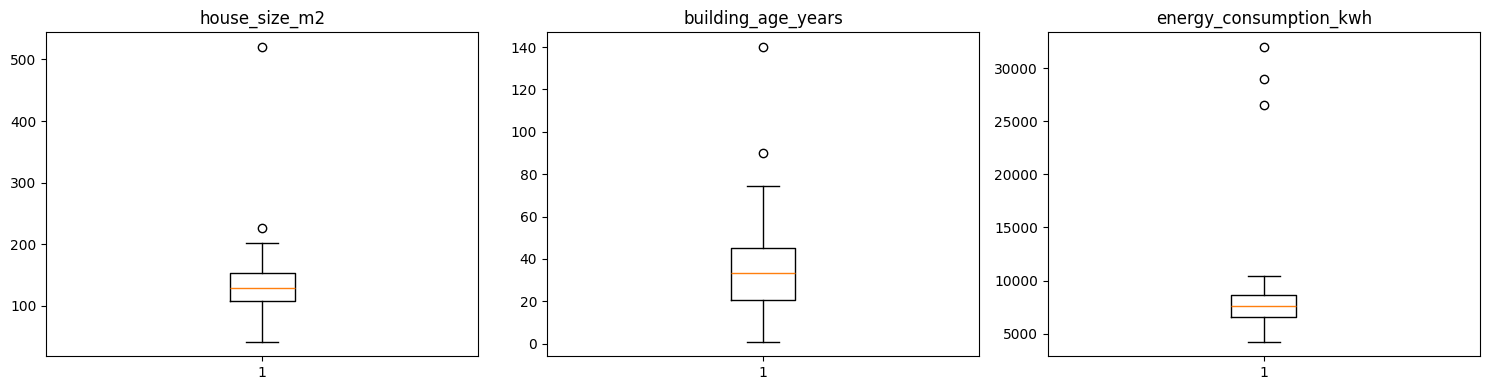

In [9]:
# Quick statistical view
display(df_no_duplicates[['house_size_m2', 'building_age_years', 'energy_consumption_kwh']].describe())

# Boxplots for visual outlier detection
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].boxplot(df_no_duplicates['house_size_m2'])
axes[0].set_title('house_size_m2')

axes[1].boxplot(df_no_duplicates['building_age_years'])
axes[1].set_title('building_age_years')

axes[2].boxplot(df_no_duplicates['energy_consumption_kwh'])
axes[2].set_title('energy_consumption_kwh')

plt.tight_layout()
plt.show()

### IQR-Based Outlier Flags
We use the Interquartile Range (IQR) rule to flag potential outliers:

- `Q1`: 25th percentile
- `Q3`: 75th percentile
- `IQR = Q3 - Q1`
- lower bound: `Q1 - 1.5 * IQR`
- upper bound: `Q3 + 1.5 * IQR`

In [10]:
def iqr_outlier_flags(dataframe, col):
    Q1 = dataframe[col].quantile(0.25)
    Q3 = dataframe[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    flags = (dataframe[col] < lower) | (dataframe[col] > upper)
    return flags, lower, upper

for col in ['house_size_m2', 'building_age_years', 'energy_consumption_kwh']:
    flags, lower, upper = iqr_outlier_flags(df_no_duplicates, col)
    print(f'{col}: {flags.sum()} potential outliers | lower={lower:.2f}, upper={upper:.2f}')

house_size_m2: 2 potential outliers | lower=41.61, upper=219.51


building_age_years: 2 potential outliers | lower=-16.62, upper=82.38
energy_consumption_kwh: 3 potential outliers | lower=3386.34, upper=11857.64


## 9) Basic Noise Visualization
Noise means random fluctuation in values.
A rolling mean can smooth short-term variation and reveal broad trends.

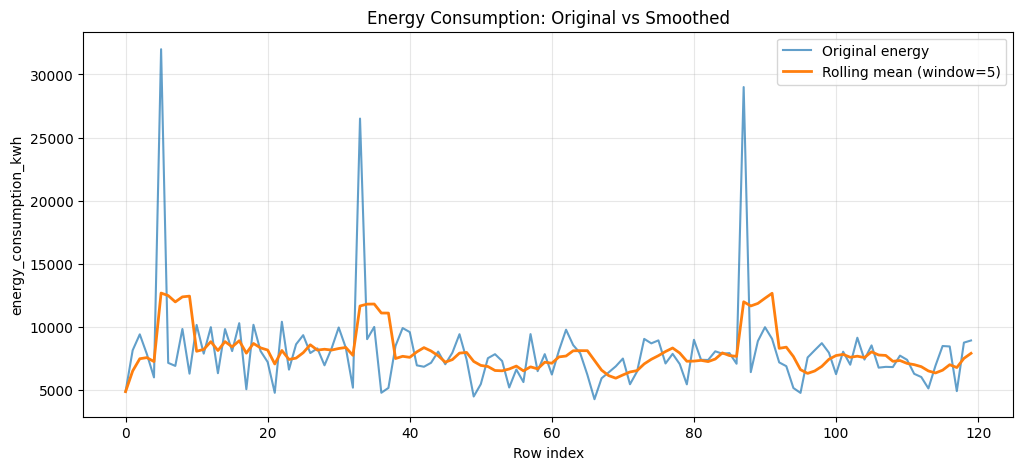

In [11]:
df_noise = df_no_duplicates.copy()
df_noise['energy_smoothed'] = df_noise['energy_consumption_kwh'].rolling(window=5, min_periods=1).mean()

plt.figure(figsize=(12, 5))
plt.plot(df_noise.index, df_noise['energy_consumption_kwh'], label='Original energy', alpha=0.7)
plt.plot(df_noise.index, df_noise['energy_smoothed'], label='Rolling mean (window=5)', linewidth=2)
plt.title('Energy Consumption: Original vs Smoothed')
plt.xlabel('Row index')
plt.ylabel('energy_consumption_kwh')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Smoothing helps detect the broader pattern, but it can hide sudden important changes.
Use it as a diagnostic tool, not as automatic truth.

## 10) Encoding Categorical Variables
Most ML algorithms require numerical inputs, so categorical values must be encoded.

In [12]:
categorical_cols = ['city', 'heating_type', 'insulation_grade']

# Pandas one-hot encoding
dummies = pd.get_dummies(df_no_duplicates[categorical_cols], drop_first=False)
print('Pandas encoded shape:', dummies.shape)
display(dummies.head())

Pandas encoded shape: (120, 13)


,city_Berlin,city_Cologne,city_Hamburg,city_Leipzig,city_Munich,heating_type_District,heating_type_Electric,heating_type_Gas,heating_type_Heat Pump,insulation_grade_A,insulation_grade_B,insulation_grade_C,insulation_grade_D
0,True,False,False,False,False,False,False,False,True,False,True,False,False
1,True,False,False,False,False,False,True,False,False,False,False,True,False
2,False,False,False,True,False,False,True,False,False,False,False,True,False
3,False,False,False,False,True,False,True,False,False,False,True,False,False
4,False,False,False,False,True,False,False,True,False,True,False,False,False


In [13]:
# Scikit-learn one-hot encoding
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
encoded_array = ohe.fit_transform(df_no_duplicates[categorical_cols])
encoded_feature_names = ohe.get_feature_names_out(categorical_cols)
encoded_df = pd.DataFrame(encoded_array, columns=encoded_feature_names, index=df_no_duplicates.index)

print('Scikit-learn encoded shape:', encoded_df.shape)
display(encoded_df.head())

Scikit-learn encoded shape: (120, 13)


,city_Berlin,city_Cologne,city_Hamburg,city_Leipzig,city_Munich,heating_type_District,heating_type_Electric,heating_type_Gas,heating_type_Heat Pump,insulation_grade_A,insulation_grade_B,insulation_grade_C,insulation_grade_D
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
1,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0


Why `handle_unknown='ignore'`?
- During prediction, new categories can appear (for example, a new city not seen in training).
- `ignore` prevents errors by safely handling unseen categories.

## 11) Feature Scaling
Numerical features can have very different ranges. Scaling helps many algorithms treat features more fairly.

Formulas:
- StandardScaler: `z = (x - mean) / standard deviation`
- MinMaxScaler: `x_scaled = (x - x_min) / (x_max - x_min)`

In [14]:
numerical_cols = ['house_size_m2', 'bedrooms', 'building_age_years', 'average_temperature_c']

num_data = df_no_duplicates[numerical_cols].copy()

# Fill any remaining numerical missing values before standalone scaling demo
num_data = num_data.fillna(num_data.median())

standard_scaler = StandardScaler()
minmax_scaler = MinMaxScaler()

num_standard_scaled = pd.DataFrame(
    standard_scaler.fit_transform(num_data),
    columns=[f'{c}_std' for c in numerical_cols]
)

num_minmax_scaled = pd.DataFrame(
    minmax_scaler.fit_transform(num_data),
    columns=[f'{c}_mm' for c in numerical_cols]
)

print('Before scaling summary:')
display(num_data.describe().round(2))

print('After StandardScaler summary:')
display(num_standard_scaled.describe().round(2))

print('After MinMaxScaler summary:')
display(num_minmax_scaled.describe().round(2))

Before scaling summary:


,house_size_m2,bedrooms,building_age_years,average_temperature_c
count,120.00,120.00,120.00,120.00
mean,131.15,3.67,34.05,10.93
std,49.60,1.47,21.43,5.37
min,42.20,1.00,1.00,-18.00
25%,108.32,3.00,20.50,7.90
50%,128.50,4.00,33.20,11.25
75%,152.80,4.25,45.25,14.25
max,520.00,10.00,140.00,21.20


After StandardScaler summary:


,house_size_m2_std,bedrooms_std,building_age_years_std,average_temperature_c_std
count,120.00,120.00,120.00,120.00
mean,-0.00,0.00,-0.00,-0.00
std,1.00,1.00,1.00,1.00
min,-1.80,-1.82,-1.55,-5.41
25%,-0.46,-0.45,-0.63,-0.57
50%,-0.05,0.23,-0.04,0.06
75%,0.44,0.40,0.52,0.62
max,7.87,4.31,4.96,1.92


After MinMaxScaler summary:


,house_size_m2_mm,bedrooms_mm,building_age_years_mm,average_temperature_c_mm
count,120.00,120.00,120.00,120.00
mean,0.19,0.30,0.24,0.74
std,0.10,0.16,0.15,0.14
min,0.00,0.00,0.00,0.00
25%,0.14,0.22,0.14,0.66
50%,0.18,0.33,0.23,0.75
75%,0.23,0.36,0.32,0.82
max,1.00,1.00,1.00,1.00


- **StandardScaler** is common for distance-based and gradient-based methods.
- **MinMaxScaler** is useful when we want bounded values (0 to 1).

## 12) Basic Feature Engineering
Feature engineering creates new informative variables from existing columns.

In [15]:
df_features = df_no_duplicates.copy()

# Feature 1: normalize energy by size
df_features['energy_per_m2'] = df_features['energy_consumption_kwh'] / df_features['house_size_m2']

# Feature 2: age group category
df_features['age_group'] = pd.cut(
    df_features['building_age_years'],
    bins=[0, 10, 30, 60, np.inf],
    labels=['New', 'Mid-age', 'Old', 'Very old']
)

# Feature 3: interaction between climate and size
df_features['cold_large_house'] = df_features['average_temperature_c'] * df_features['house_size_m2']

# Optional feature 4: old building indicator
df_features['is_old_building'] = (df_features['building_age_years'] > 40).astype(int)

display(df_features[['energy_per_m2', 'age_group', 'cold_large_house', 'is_old_building']].head())

,energy_per_m2,age_group,cold_large_house,is_old_building
0,33.730689,Mid-age,2327.94,0
1,97.697115,Old,507.52,0
2,57.333944,New,1048.32,0
3,45.399884,New,2377.74,0
4,141.694313,Very old,417.78,1


Why these engineered features may help:
- `energy_per_m2`: compares consumption fairly across small and large homes.
- `age_group`: converts continuous age into meaningful building-life categories.
- `cold_large_house`: interaction feature that can capture combined climate-size effects.
- `is_old_building`: simple binary indicator that may separate older stock quickly.

## 13) Build a Clean Preprocessing Pipeline
Now we combine imputation, encoding, and scaling in one reproducible pipeline.

In [16]:
# Define feature sets for preprocessing
numerical_features = ['house_size_m2', 'bedrooms', 'building_age_years', 'average_temperature_c']
categorical_features = ['city', 'heating_type', 'insulation_grade']

X_raw = df.drop(columns=['energy_consumption_kwh'])

# Numeric pipeline: fill missing with median, then scale
numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical pipeline: fill missing with most frequent, then one-hot encode
categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# ColumnTransformer applies each pipeline to selected columns
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_pipeline, numerical_features),
    ('cat', categorical_pipeline, categorical_features)
])

# fit: learn statistics from data (medians, categories, scaling params)
# transform: apply learned steps to data
# fit_transform: do both in one step
X_transformed = preprocessor.fit_transform(X_raw)

print('Transformed feature matrix type:', type(X_transformed))
print('Transformed feature matrix shape:', X_transformed.shape)

Transformed feature matrix type: <class 'numpy.ndarray'>
Transformed feature matrix shape: (122, 17)


Component explanation:
- `SimpleImputer`: fills missing values using a chosen rule.
- `StandardScaler`: standardizes numeric features for comparable scale.
- `OneHotEncoder`: turns categories into machine-readable binary columns.
- `ColumnTransformer`: applies the right preprocessing to the right columns.
- `Pipeline`: keeps steps ordered, reproducible, and easy to reuse.
- `fit`: learns parameters from data.
- `transform`: applies learned parameters to data.
- `fit_transform`: convenience method for fit + transform.

**Important note:** In a real ML workflow, preprocessing should be fitted on the training data only, then applied to validation/test data. This prevents data leakage.

## 14) Final Dataset Readiness Checklist

Before model training, check:
- [x] target is clearly defined
- [x] features are selected
- [x] missing values are handled
- [x] duplicates are checked
- [x] outliers are inspected
- [x] categorical variables are encoded
- [x] numerical variables are scaled if needed
- [x] engineered features are created carefully
- [x] preprocessing is organized in a pipeline

## 15) In-Class Task

Complete the following TODOs:
1. Choose **two additional features** that might improve prediction.
2. Create **one new engineered feature** from existing columns.
3. Check whether it has missing or extreme values.
4. Add it to the preprocessing plan.
5. Write **3 to 5 sentences** explaining why it may help.

## 16) Final Output
We summarize data readiness metrics for Day 1.

In [17]:
original_shape = df.shape
cleaned_shape = df_no_duplicates.shape
num_feature_count = len(numerical_features)
cat_feature_count = len(categorical_features)

print('Day 1 dataset preparation completed successfully.')
print('Original dataset shape:', original_shape)
print('Cleaned dataset shape:', cleaned_shape)
print('Number of numerical features:', num_feature_count)
print('Number of categorical features:', cat_feature_count)
print('Transformed feature matrix shape:', X_transformed.shape)

Day 1 dataset preparation completed successfully.
Original dataset shape: (122, 8)
Cleaned dataset shape: (120, 8)
Number of numerical features: 4
Number of categorical features: 3
Transformed feature matrix shape: (122, 17)
